In [1]:
# Install the advanced deep learning and signal processing libraries
%pip install torch torchvision librosa soundfile matplotlib numpy pandas scikit-learn


Defaulting to user installation because normal site-packages is not writeable
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached cffi-2.0.0-cp312-cp312-win_amd64.whl.metadata (2.6 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached markupsafe-3.0.3-cp312-cp312-win_amd64.whl.metadata (2.8 kB)
  Using cached charset_normalizer-3.4.7-cp312-cp312-win_amd64.whl.metadata (41 kB)
  Using cached idna-3.18-py3-none-any.whl.metadata (6.1 kB)
  Using cached certifi-2026.5.20-py3-none-any.whl.metadata (2.5 kB)
   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/123.0 MB 4.2 MB/s eta 0:00:29
   ---------------------------------------- 0.8/123.0 MB 2.0 MB/s eta 0:01:02
   ---------------------------------------- 1.0/123.0 MB 1.3 MB/s eta 0:01:37
   ---------------------------------------- 1.0/123.0 MB 1.3


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


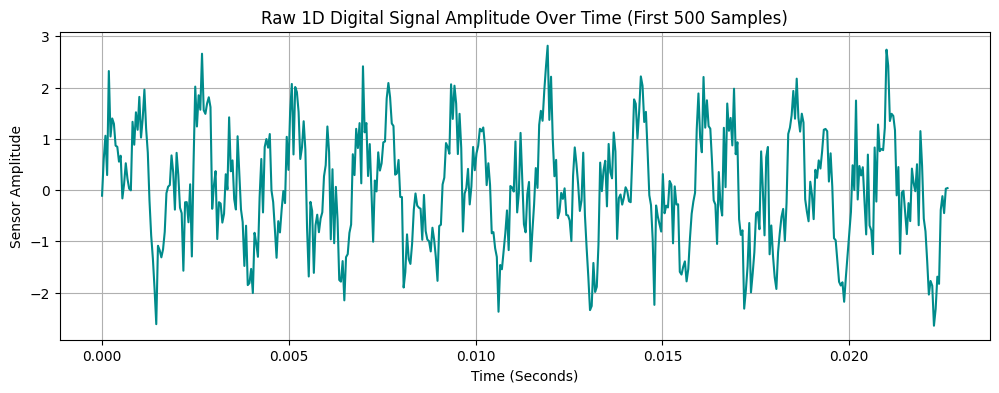

Total numeric data points in our 1-second wave: 22050


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define physical constants
sampling_rate = 22050  # Number of data points captured per second (Hz)
duration = 1.0         # Duration of our signal sample in seconds
t = np.linspace(0, duration, int(sampling_rate * duration), endpoint=False)

# 2. Mathematically construct the wave using trigonometric sine functions
# Signal = sin(2 * pi * f1 * t) + sin(2 * pi * f2 * t)
low_hum = np.sin(2 * np.pi * 440 * t)
high_squeal = np.sin(2 * np.pi * 1200 * t)
raw_signal = low_hum + high_squeal

# 3. Add random background factory floor noise to make it realistic
noise = np.random.normal(0, 0.5, raw_signal.shape)
noisy_signal = raw_signal + noise

# 4. Visualize the raw 1D signal array
plt.figure(figsize=(12, 4))
plt.plot(t[:500], noisy_signal[:500], color='darkcyan')
plt.title("Raw 1D Digital Signal Amplitude Over Time (First 500 Samples)")
plt.xlabel("Time (Seconds)")
plt.ylabel("Sensor Amplitude")
plt.grid(True)
plt.show()

print(f"Total numeric data points in our 1-second wave: {len(noisy_signal)}")

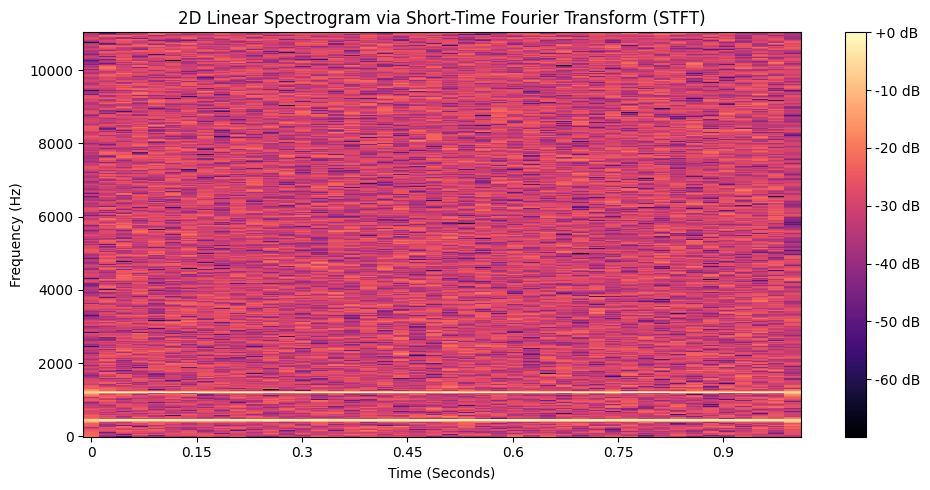

STFT Matrix Numeric Shape: (513, 44)


In [3]:
import librosa
import librosa.display

# 1. Compute the Short-Time Fourier Transform (STFT)
# n_fft is our window size (how many data slices to look at at once)
stft_matrix = librosa.stft(noisy_signal, n_fft=1024, hop_length=512)

# 2. Convert raw amplitude values to Decibels (dB) on a logarithmic scale
# This matches how human ears and microphone sensors actually perceive volume
stft_db = librosa.amplitude_to_db(np.abs(stft_matrix), ref=np.max)

# 3. Plot the Spectrogram visualization
plt.figure(figsize=(10, 5))
librosa.display.specshow(stft_db, sr=sampling_rate, hop_length=512, x_axis='time', y_axis='linear', cmap='magma')
plt.colorbar(format='%+2.0f dB')
plt.title("2D Linear Spectrogram via Short-Time Fourier Transform (STFT)")
plt.xlabel("Time (Seconds)")
plt.ylabel("Frequency (Hz)")
plt.tight_layout()
plt.show()

print(f"STFT Matrix Numeric Shape: {stft_matrix.shape}")

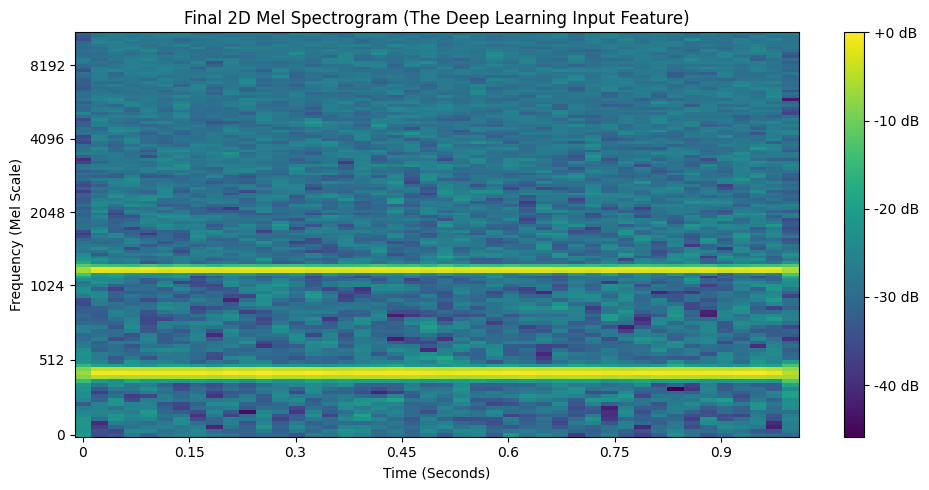

Mel Spectrogram Tensor Shape: (128, 44)


In [4]:
# 1. Compute a Mel-scaled Spectrogram directly from our raw signal
# n_mels=128 creates 128 distinct mathematical frequency channels
mel_spectrogram = librosa.feature.melspectrogram(y=noisy_signal, sr=sampling_rate, n_fft=1024, hop_length=512, n_mels=128)

# 2. Convert the power spectrogram to decibel units (dB)
mel_db = librosa.power_to_db(mel_spectrogram, ref=np.max)

# 3. Plot the final Mel Spectrogram
plt.figure(figsize=(10, 5))
librosa.display.specshow(mel_db, sr=sampling_rate, hop_length=512, x_axis='time', y_axis='mel', cmap='viridis')
plt.colorbar(format='%+2.0f dB')
plt.title("Final 2D Mel Spectrogram (The Deep Learning Input Feature)")
plt.xlabel("Time (Seconds)")
plt.ylabel("Frequency (Mel Scale)")
plt.tight_layout()
plt.show()

print(f"Mel Spectrogram Tensor Shape: {mel_db.shape}")

In [3]:
import numpy as np
import librosa

# 1. Define a function to generate a specific signal matrix on demand
def generate_simulated_mel(label):
    t = np.linspace(0, 1.0, 22050, endpoint=False)
    
    if label == 0:
        # Normal operations: Only the standard hum
        signal = np.sin(2 * np.pi * 440 * t)
    else:
        # Fault operations: The hum + a severe friction screech
        signal = np.sin(2 * np.pi * 440 * t) + 1.5 * np.sin(2 * np.pi * 1500 * t)
        
    # Add heavy industrial background noise
    signal += np.random.normal(0, 0.8, signal.shape)
    
    # Compute Mel Spectrogram
    mel = librosa.feature.melspectrogram(y=signal, sr=22050, n_fft=1024, hop_length=512, n_mels=128)
    return librosa.power_to_db(mel, ref=np.max)

# 2. Build our dataset arrays manually using NumPy loops
X_data = []
y_labels = []

num_samples = 200
for i in range(num_samples):
    label = 0 if i < num_samples // 2 else 1
    mel_matrix = generate_simulated_mel(label)
    
    # Add an explicit single channel dimension at the front (1, 128, 44) for deep learning structure
    mel_matrix_with_channel = np.expand_dims(mel_matrix, axis=0)
    
    X_data.append(mel_matrix_with_channel)
    y_labels.append(label)

# Convert lists into final high-performance NumPy arrays
X_data = np.array(X_data)
y_labels = np.array(y_labels)

print(f"Dataset successfully created with {X_data.shape[0]} samples!")
print(f"Full Feature Matrix Shape: {X_data.shape}  | Full Labels Shape: {y_labels.shape}")

Dataset successfully created with 200 samples!
Full Feature Matrix Shape: (200, 1, 128, 44)  | Full Labels Shape: (200,)


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Flatten the 2D visual spectrogram arrays into a 1D feature row per sample
# (200, 1, 128, 44) becomes (200, 128 * 44) = (200, 5632)
num_samples = X_data.shape[0]
X_flattened = X_data.reshape(num_samples, -1)

# 2. Perform a Stratified Split to maintain exact normal/fault distributions
X_train, X_test, y_train, y_test = train_test_split(
    X_flattened, y_labels, test_size=0.3, random_state=42, stratify=y_labels
)

# 3. Instantiate a Deep Neural Network (Multi-Layer Perceptron)
# We will create two hidden layers: Layer 1 has 100 neurons, Layer 2 has 50 neurons
mlp_model = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation='relu',       # Rectified Linear Unit activation function
    solver='adam',           # Advanced gradient descent optimization algorithm
    max_iter=300,            # Max optimization epochs
    random_state=42
)

print("Flattening step complete! Training the Neural Network model now...")
# 4. Train the Neural Network
mlp_model.fit(X_train, y_train)
print("Neural Network training finished successfully!")

Flattening step complete! Training the Neural Network model now...
Neural Network training finished successfully!


In [ ]:
# 1. Generate predictions on the unseen test data split
y_pred = mlp_model.predict(X_test)

# 2. Print out the comprehensive engineering performance metrics
print("=== DEEP NEURAL NETWORK EVALUATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=['Normal Hum (Class 0)', 'Friction Fault (Class 1)']))

# 3. Print out the underlying mathematical Confusion Matrix
print("=== CONFUSION MATRIX ===")
print(confusion_matrix(y_test, y_pred))

=== DEEP NEURAL NETWORK EVALUATION REPORT ===
                          precision    recall  f1-score   support

    Normal Hum (Class 0)       1.00      1.00      1.00        30
Friction Fault (Class 1)       1.00      1.00      1.00        30

                accuracy                           1.00        60
               macro avg       1.00      1.00      1.00        60
            weighted avg       1.00      1.00      1.00        60

=== CONFUSION MATRIX ===
[[30  0]
 [ 0 30]]


: 

In [8]:
%pip install --upgrade --force-reinstall torch torchvision --index-url https://download.pytorch.org/cli/cpu

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/cli/cpu
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement torch (from versions: none)

[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for torch


In [1]:
%pip install --upgrade --force-reinstall torch torchvision --index-url https://download.pytorch.org/whl/cpu

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cpu
  Using cached https://download-r2.pytorch.org/whl/cpu/torch-2.12.0%2Bcpu-cp312-cp312-win_amd64.whl.metadata (32 kB)
  Using cached https://download-r2.pytorch.org/whl/cpu/torchvision-0.27.0%2Bcpu-cp312-cp312-win_amd64.whl.metadata (5.6 kB)
  Using cached filelock-3.29.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached https://download.pytorch.org/whl/typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached https://download.pytorch.org/whl/setuptools-70.2.0-py3-none-any.whl.metadata (5.8 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached https://download.pytorch.org/whl/jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2026.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached numpy-2.4.4-cp312-cp312-win_amd64.whl.metadata


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
